<a href="https://colab.research.google.com/github/matinbyrml/xai/blob/main/Local_explanation_methods_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 3 - Explainable and Trustworthy AI**


---



**Teaching Assistant**: Eleonora Poeta (eleonora.poeta@polito.it)

**Lab 3b:** Local post-hoc explainable models on structured data - SHAP


## **SHAP**



---


**SHAP** (**SH**apley **A**dditive ex**P**lanations) is a local explanation method designed to explain **individual predictions**. By dissecting the prediction of a specific *x* instance, it calculates the contribution of each feature to the outcome.

* Based on the theory of **Shapley values**, SHAP ensures a fair distribution of *credit* for collaborative tasks.

* Within SHAP, **each characteristic value** assumes the role of a **strategic "player "** in a predictive "game". The final goal of the *game* is to predict the outcome of a given instance, with each characteristic influencing the final prediction.




---

We will use of **SHAP** to explain the predictions of individual instances of the [Adult dataset](https://archive.ics.uci.edu/dataset/2/adult).



> The Adult dataset, also known as the "Census Income" dataset, contains demographic information about people, such as age, education, occupation, marital status and more, extracted from the 1994 U.S. Census Bureau database. **Each entry** in the dataset represents a **person**, and the associated **task** is to **predict whether an individual earns more than $50,000 per year** or less.

First, we will load the dataset and train a Random Forest classifier. We will perform this steps:
a. **Install** **SHAP** library.
b. **Load** the Adult dataset.
  * SHAP provides an instance of the Adult dataset directly into its [library](https://shap.readthedocs.io/en/latest/generated/shap.datasets.adult.html).
  * In particular, SHAP provides **two versions of Adult dataset:**
    * The first version is **already preprocessed**; therefore, it has neither missing values nor categorical values. We will use this version of the dataset for both the classifier and the explainer.
    * The second version is the **original** one. This is valuable for our SHAP analysis, as it produces results that are inherently meaningful and easily interpreted. For example, instead of denoting a feature as "feature_0=45", we obtain a more intuitive representation, such as "Age=45".

c. Split the Adult dataset. 80/20 train-test ratio.
d. Train a RandomForestClassifier and fit it over the training dataset. Evaluate the model.


Exercise.
1. Use the `shap.Explainer` to explain the instances `id=1` and `id=7` .

2. Local Explanations:
  * 2.1 **Plot** with a bar chart from `matplotlib.pyplot` the **Shapley values** for the instances `id=1` and `id=7` .
  * 2.2 Plot the shap explanation for the instances `id=1` and `id=7` with:
      * 2.2a [`shap.force_plot`](https://shap-lrjball.readthedocs.io/en/latest/generated/shap.force_plot.html)
      * 2.2b [`shap.waterfall_plot`](https://shap-lrjball.readthedocs.io/en/latest/generated/shap.waterfall_plot.html)

3. Global (for all features) Explanations:
  * Plot the shap explanation for the instances `id=1` and `id=7` with:
      * 3.1 [`shap.summary_plot`](https://shap-lrjball.readthedocs.io/en/latest/generated/shap.summary_plot.html)
      * 3.2 [`shap.dependence_plot`](https://shap-lrjball.readthedocs.io/en/latest/generated/shap.dependence_plot.html)
      * 3.3 `shap.force_plot`

4. Bonus: Do again point 1.) with [`shap.KernelExplainer`](https://shap.readthedocs.io/en/latest/generated/shap.KernelExplainer.html) and [`shap.ExactExplainer`](https://shap.readthedocs.io/en/latest/generated/shap.ExactExplainer.html)



Before starting, install SHAP

In [1]:
# pip install shap
# pip install shap --upgrade

# Data loading and preprocessing

In [23]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import shap

# To visualize shap plots
shap.initjs()

#### Load dataset

In [3]:
X, y = shap.datasets.adult()
X

,Age,Workclass,Education-Num,Marital Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country
0,39.0,7,13.0,4,1,0,4,1,2174.0,0.0,40.0,39
1,50.0,6,13.0,2,4,4,4,1,0.0,0.0,13.0,39
2,38.0,4,9.0,0,6,0,4,1,0.0,0.0,40.0,39
3,53.0,4,7.0,2,6,4,2,1,0.0,0.0,40.0,39
4,28.0,4,13.0,2,10,5,2,0,0.0,0.0,40.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27.0,4,12.0,2,13,5,4,0,0.0,0.0,38.0,39
32557,40.0,4,9.0,2,7,4,4,1,0.0,0.0,40.0,39
32558,58.0,4,9.0,6,1,1,4,0,0.0,0.0,40.0,39
32559,22.0,4,9.0,4,1,3,4,1,0.0,0.0,20.0,39


In [4]:
# Load the data with display=True. This dataset still contains the categorical values.
X_display, y_display = shap.datasets.adult(display=True)

#### Split dataset

In [5]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Train the Random Forest Classifier

In [6]:
# Train a RandomForestClassifier

from sklearn.linear_model import LogisticRegression
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)

RandomForestClassifier()

In [7]:
# Evaluate the model
accuracy = rf_clf.score(X_test, y_test)
accuracy

0.8552126516198373

# SHAP - Explainer

[`shap.Explainer`](https://shap.readthedocs.io/en/latest/generated/shap.Explainer.html) wants as parameters:


* A model object or a **prediction function** that computes the output of the model. We will use the **function** of the model that **predicts the probabilities of the classes** you are using (e.g. `.predict_proba` if you are using the Random Forest).
* A **`masker`**. The masker parameter in the SHAP explainer is an optional argument that allows you to **specify** a **masking function** for the input data. The masking function defines *how certain features are masked* or hidden during the explanation process.
  
  * Using the masker `shap.maskers.Independent(data=X_train)` you can do **Dataset-Based Masking** (via marginalization). In this case the masking behavior is derived from the provided dataset. The masker calculates summary statistics from the dataset (such as means, medians, or quantiles) and uses them to mask the features during the explanation process.





When using `explainer = shap.Explainer` you can have two results:


1.   From `explainer(X)` you obtain **shap_values_explanation** that does not only contains Shap values. It is an **Explanation** **object**.
  * For reasons of computational time, we will select a subset of the data set (`sample_data`) to provide to the explainer. Only the first 100 rows.
2.   From `explainer.shap_values(X)` you obtain a `numpy.ndarray` that contains *only* the Shapley values.
  * We are interested in explaining the Shapley values for the `class_label = 0`. So, you have to take only the shapley_values of this class.
3. We can also compute the **expected_value**.
  * In SHAP library the expected value is called `base_values`. Again you have to select only the one related to the class we want to explain (class 0).





#### Sample data

In [9]:
# Select the first 100 rows of the X dataset. This is the sample_data.
sample_data = X.loc[:100]

# Select the first 100 rows of the X_display dataset.
sample_X_display = X_display.loc[:100]

# 1. Explain an instance via SHAP

✍️ Initialize SHAP

In [10]:
# Compute the masker
# Use the Independent masker, which assumes feature independence.
# It masks out tabular features by integrating over the given background dataset.
# The masker will use the training data to compute the expected value of the features.

# 2. Create the Masker
masker = shap.maskers.Independent(data=sample_data)

# 3. Build the SHAP Explainer using our Black-Box probabilities and the Masker
explainer = shap.Explainer(rf_clf.predict_proba, masker)

# 4. Grab the specific passengers/instances the lab asked for (id=1 and id=7)
# We will pull these from the Test set.
instances_to_explain = X_test.iloc[[1, 7]]

# 5. Calculate the SHAP values! (This creates a massive 'Explanation' object)
shap_values = explainer(instances_to_explain)

# 6. Isolate Class 0 (<=$50k) because the lab instructions told us to focus on it
shap_values_class0 = shap_values[:, :, 0]
#### END CODE HERE ####

print("✅ SHAP Explainer built and values calculated!")

PermutationExplainer explainer: 3it [00:12,  6.43s/it]

✅ SHAP Explainer built and values calculated!


In [11]:
# Analyze which type of approximation is used by default by SHAP
explainer

✍️ Explain the sample_data instances using the explainer. User explainer()

1.   List item
2.   List item



In [13]:
#### START CODE HERE ####
#  Select the subset data to explain
sample_data = X_train.iloc[:100]

#  Instantiate the masker Independent
masker = shap.maskers.Independent(data=sample_data)

#  Instantiate the explainer
explainer = shap.Explainer(rf_clf.predict_proba, masker)

#  Explain the sample_data instances using the explainer. User explainer()
shap_values_explanation = explainer(sample_data)

#  Print of the Shapley values
print(shap_values_explanation.values)
#### END CODE HERE ####

PermutationExplainer explainer: 101it [01:35,  1.01s/it]

[[[-6.84263924e-02  6.84263924e-02]
  [-3.71312068e-02  3.71312068e-02]
  [-1.46231683e-01  1.46231683e-01]
  ...
  [ 5.13308333e-03 -5.13308333e-03]
  [-9.71293329e-02  9.71293329e-02]
  [-8.63499278e-03  8.63499278e-03]]

 [[-4.89259919e-02  4.89259919e-02]
  [-1.26113234e-02  1.26113234e-02]
  [-2.35417590e-02  2.35417590e-02]
  ...
  [-2.38156062e-01  2.38156062e-01]
  [-1.00009260e-01  1.00009260e-01]
  [-3.45828006e-04  3.45828006e-04]]

 [[-3.60310592e-02  3.60310592e-02]
  [ 4.35830914e-03 -4.35830914e-03]
  [ 7.89683780e-02 -7.89683780e-02]
  ...
  [ 9.42551272e-03 -9.42551272e-03]
  [ 1.69710648e-02 -1.69710648e-02]
  [ 1.33945059e-03 -1.33945059e-03]]

 ...

 [[ 3.15599239e-02 -3.15599239e-02]
  [-3.24674838e-03  3.24674838e-03]
  [-4.91180371e-03  4.91180371e-03]
  ...
  [ 9.56491667e-03 -9.56491667e-03]
  [ 4.07513496e-02 -4.07513496e-02]
  [ 1.64183975e-03 -1.64183975e-03]]

 [[ 3.82804609e-02 -3.82804609e-02]
  [ 5.10687302e-02 -5.10687302e-02]
  [ 3.63599402e-03 -3.6359

Print of the Shapley values

In [14]:
# Print the shap_values_explanation
print(type(shap_values_explanation))
print(shap_values_explanation[0])
print('-' * 80)

# Class for which we want to analyze the shapley values
class_index = 0  # Note that being a binary classification problem, the shapley values for the other class are -(shapley values of the class_index)

# Calculate the Shapley values with explainer.shap_values( ... )
shap_values_ndarray = explainer.shap_values(sample_data)[:, :, class_index]

print(type(shap_values_ndarray))
print(shap_values_ndarray[0])


# Calculate the expected_value
expected_value = shap_values_explanation.base_values[0][class_index] # this is the expected value for the class we want to explain -> class 0


<class 'shap._explanation.Explanation'>
.values =
array([[-0.06842639,  0.06842639],
       [-0.03713121,  0.03713121],
       [-0.14623168,  0.14623168],
       [ 0.02164895, -0.02164895],
       [-0.06975546,  0.06975546],
       [ 0.01573017, -0.01573017],
       [-0.00769425,  0.00769425],
       [-0.01719968,  0.01719968],
       [ 0.0168647 , -0.0168647 ],
       [ 0.00513308, -0.00513308],
       [-0.09712933,  0.09712933],
       [-0.00863499,  0.00863499]])

.base_values =
array([0.75282609, 0.24717391])

.data =
array([33.,  2., 13.,  4., 10.,  0.,  4.,  0.,  0.,  0., 50., 39.])
--------------------------------------------------------------------------------


PermutationExplainer explainer: 101it [00:19,  2.45it/s]

<class 'numpy.ndarray'>
[-0.03759888  0.00483077 -0.15383666  0.03563951 -0.08438971  0.04050843
 -0.00667208 -0.04089021  0.01323926  0.00865802 -0.16670153 -0.00561299]


In [ ]:
shap_values_ndarray.shape

(101, 12)

In [ ]:
shap_values_ndarray[0]

array([ 0.00162977,  0.02004027, -0.02507505,  0.06770705,  0.03695952,
        0.10208317, -0.00026563, -0.00424566,  0.03388392,  0.00394757,
        0.02257015,  0.00202   ])

# 2. Indiviual/Local insights - Plots

## 2.1 Bar plots

✍️ Extract the Shapley values for all the sample data instances and for the 'class_index' as target class

In [17]:
#### START CODE HERE ####
# 1. Grab instances id=1 and id=7 from the test set
instances = X_test.iloc[[1, 7]]

# 2. Calculate the Explanation object (The "New Way" - needed for Waterfalls)
explanations = explainer(instances)

# 3. Calculate the raw arrays (The "Old Way" - needed for Force Plots & Matplotlib)
raw_shap_values = explainer.shap_values(instances)

# 4. Isolate the raw SHAP values specifically for Class 0
shap_vals_class0 = raw_shap_values[:, :, 0]
#### END CODE HERE ####

print("✅ SHAP values calculated for id=1 and id=7!")# Calculate the Shapley values with explainer.shap_values( ... ).
# (alternative way to calculate the shapley values rather than using the explainer(sample_data) method and then extracting the shapley values from the explanation object)
# Consider as target the 'class_index' class
shap_values_ndarray = explainer.shap_values(sample_data)[:, :, class_index]

✅ SHAP values calculated for id=1 and id=7!


PermutationExplainer explainer: 101it [00:20,  2.39it/s]


Bar chart of Shapley values for the `id_instance=1`

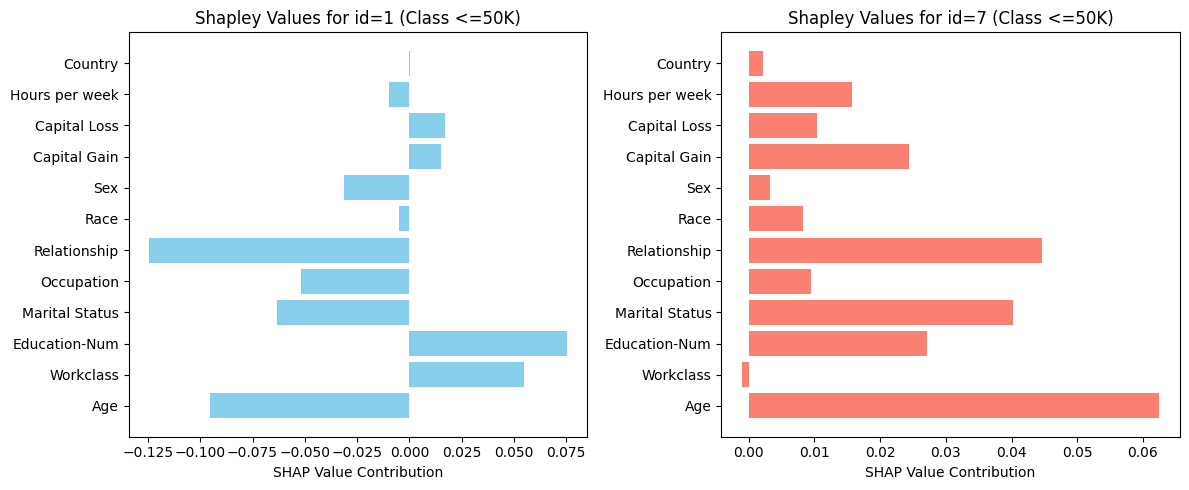

Ellipsis

In [19]:
id_instance = 1

#### START CODE HERE ####
plt.figure(figsize=(12, 5))

# Plot for id=1 (which is index 0 in our instances list)
plt.subplot(1, 2, 1)
plt.barh(X_test.columns, shap_vals_class0[0], color='skyblue')
plt.title('Shapley Values for id=1 (Class <=50K)')
plt.xlabel('SHAP Value Contribution')

# Plot for id=7 (which is index 1 in our instances list)
plt.subplot(1, 2, 2)
plt.barh(X_test.columns, shap_vals_class0[1], color='salmon')
plt.title('Shapley Values for id=7 (Class <=50K)')
plt.xlabel('SHAP Value Contribution')

plt.tight_layout()
plt.show()
#### END CODE HERE ####
...

Bar chart of Shapley values for the `id_instance=7`

## 2.2a SHAP Force plot - single instance


---

`shap.force_plot()` shows bars that indicate the **magnitude** and **direction** of the **influence of the features on the model prediction**. The graph also includes the base_value, which represents the average outcome of the model in the dataset, and an arrow indicating the final predicted value f(x) for the instance.




✍️ Plot the SHAP Force plot

In [26]:
#### START CODE HERE ####
# We plot id=1. We hand it the base_value (average), the raw shap values, and the person's actual data
import shap
shap.initjs() # <--- THIS IS THE MAGIC LINE! It loads the Javascript.
shap.force_plot(
    base_value=expected_value,
    shap_values=shap_vals_class0[0],
    features=instances.iloc[0]
)
#### END CODE HERE ####

## 2.2b SHAP - waterfall plot

`shap.waterfall_plot` graph shows a sequence of horizontal bars, each representing the contribution of a feature to the overall forecast. The **bars** are **cascaded**, where each successive bar adds to the previous one, visually illustrating **how each characteristic incrementally affects the final forecast.** Positive contributions are displayed as red arrows going on the right, and negative contributions are blue arrows on the left.

✍️ Plot the waterfall plot

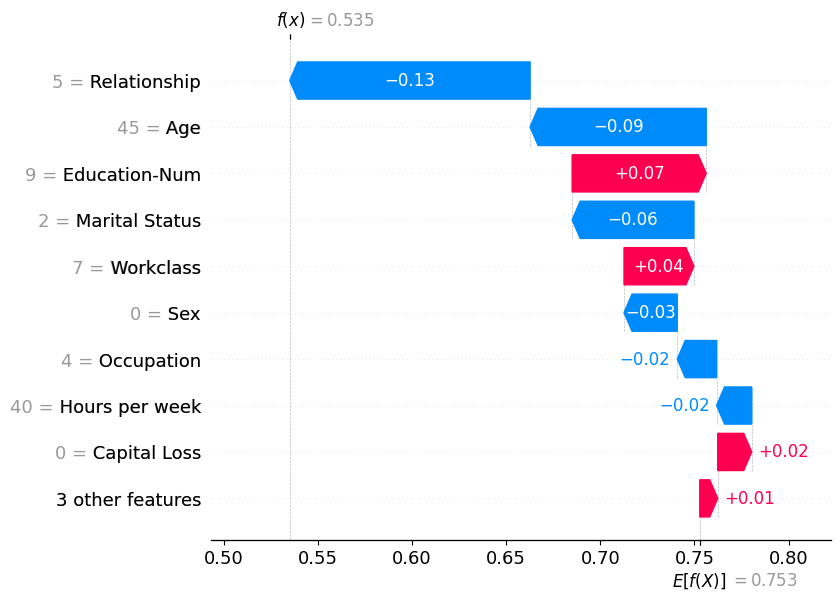

In [29]:
#### START CODE HERE ####
# We must use the 'explanations' object we created in Exercise 1.
# Slicing: [0 for id=1, : for all features, 0 for Class 0]

shap.plots.waterfall(
    shap_values=explanations[0, :, 0],
    max_display=10
)
#### END CODE HERE ####

# 3. Global insights

#### SHAP Summary plot



---

* It is used to visualize the **summary** of **SHAP values** for all features in a dataset.  This plot is particularly useful for understanding the importance and directionality of different features in influencing model predictions.

* It provides the **average impact** of each feature on the model output magnitude.

* It **aggregates** the **absolute SHAP values** for each feature across all instances and then visualizes these aggregated values.



## 3.1 Summary plot

✍️ Plot the summary plot

/tmp/ipykernel_7139/2478698888.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


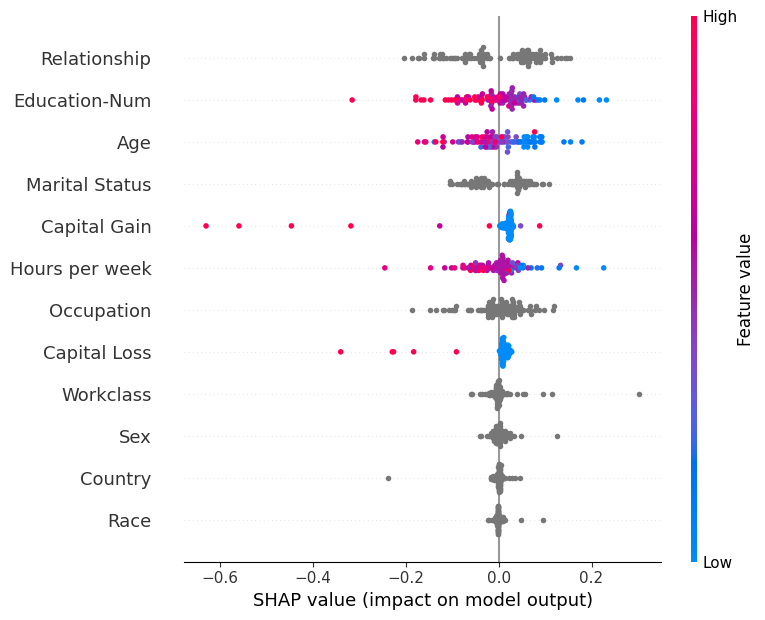

In [31]:
#### START CODE HERE ####
# We pass the raw numpy array containing all 100 people's SHAP values
shap.summary_plot(
    shap_values=shap_values_ndarray,

    # We use X_display so the chart prints English words instead of numbers
    features=X_display.loc[sample_data.index]
)
#### END CODE HERE ####

## 3.2 SHAP dependence plot



---

The graph generated by `shap.dependence_plot ` typically consists of a scatter plot in which each point represents an instance of the dataset. The x-axis represents the values of the chosen feature, while the y-axis represents the corresponding SHAP values.


✍️ Plot the SHAP dependence plot

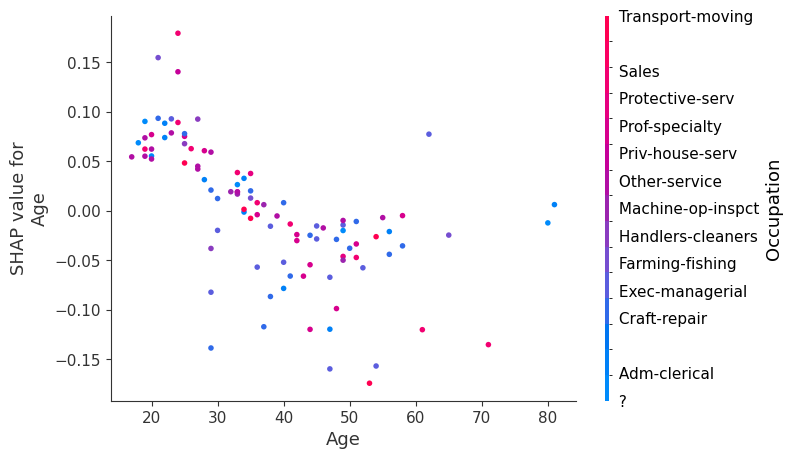

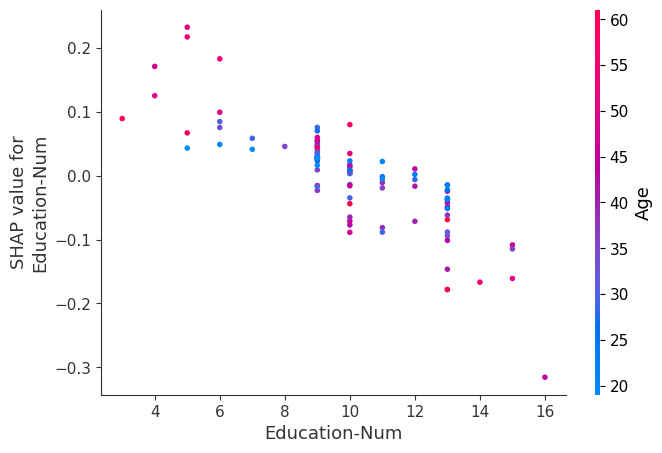

In [32]:
#### START CODE HERE ####
selected_features = ['Age', 'Education-Num']

for name in selected_features:
    shap.dependence_plot(
        ind=name,                         # The specific feature to analyze
        shap_values=shap_values_ndarray,  # The math for all 100 people
        features=sample_data,             # The raw math data
        display_features=X_display.loc[sample_data.index] # The English translation
    )
#### END CODE HERE ####

## 3.3 SHAP Force plot - multiple instances



---


For visualization reasons, if you are doing the Lab on Google Colab you can't visualize the output of the force_plot for multiple instances.

Unlikely before, now the `shap.force_plot `visualizes the impact of features across multiple instances concurrently.

In [33]:
#### START CODE HERE ####
import shap
shap.initjs() # Load the Javascript again!

# We pass the entire matrix of 100 people into the force plot
shap.force_plot(
    base_value=expected_value,
    shap_values=shap_values_ndarray,
    features=X_display.loc[sample_data.index]
)
#### END CODE HERE ####

# 4. Bonus

Redo your analysis with KernelExplainer or another Explainer